Installing and Importing Libraries

In [1]:
!pip install langgraph langchain-core langchain-google-genai python-dotenv pygithub duckduckgo-search

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from langchain_core.prompts import PromptTemplate
from typing import TypedDict, List, Dict, Optional
from pydantic import BaseModel

In [4]:
from dotenv import load_dotenv
import os
load_dotenv()

True

Defining Agent State

1. User Input: The agent receives a user query or command.
2. Requirement Analysis: The agent analyzes the input to determine the requirements and constraints.
3. Clarification: If necessary, the agent may ask follow-up questions to clarify the user's intent or gather additional information.
4. Architecture Selection: Based on the requirements, the agent selects the appropriate architecture (e.g., RAG, ReAct, Reflexion) to process the input.
5. Service Selection: The agent identifies and selects the relevant services (e.g., search engines, databases, APIs) needed to fulfill the user's request.
6. Database Design: The agent designs the database schema to store and manage the information required for processing the request.
7. Infrastructure Design: The agent plans the infrastructure needed to support the selected architecture and services, ensuring scalability and reliability.
8. Evaluation: The agent evaluates the selected architecture and services to ensure they meet the requirements and constraints of the user's request.

In [ ]:
from typing import TypedDict, List, Dict, Optional

class GraphState(TypedDict):
    user_input: str
    
    requirements: Dict
    constraints: Dict
    
    clarifications: List[str]
    
    architecture: Dict
    tech_stack: Dict
    
    services: List[Dict]
    database_design: Dict
    api_design: List[Dict]
    infrastructure: Dict
    
    validation_report: Dict
    
    final_output: Dict
    
    next_step: Optional[str]

Defining Tools and LLM

In [6]:
from langchain_community.tools import DuckDuckGoSearchRun

def web_search_tool(query: str):
    # Search the web and return results
    search = DuckDuckGoSearchRun()
    results = search.run(query)
    return results

In [7]:
web_search_tool("Which is better for web development, Python or Nodejs?")

Impersonate 'chrome_130' does not exist, using 'random'


'3 Feb 2026 · Node.js is a strong choice for real time and high concurrency workloads. But for most backend applications, Python scales well enough with good architecture, ... Node.js vs. Python for backend APIs: Which do you pick? - Reddit Why do most developers recommend Node.js, Java, or Python for backend More results from www.reddit.com 5 Nov 2025 · If you need speed, scalability, and real-time abilities, Node.js may be a better direction to take. However, if you are looking for rapid development with ease, ... 23 Jul 2025 · Python can be used for full-stack applications, IoT and machine learning. Node. js is easy to learn with prior knowledge of Javascript. 21 Aug 2025 · Node is better and suitable for web app development like real-time apps and network apps, while Python is preferred for machine learning, data analysis, and ... 23 May 2025 · js or Python usage is based on the project requirements; Python would be better for secure and scalable web solutions, while Node.js would 

In [8]:
from github import Github, Auth

auth = Auth.Token(os.getenv("GITHUB_ACCESS_TOKEN"))
gh = Github(auth=auth)

In [9]:
repo = gh.get_repo("lalor/todolist")

In [10]:
repo.get_contents('/')

[ContentFile(path=".gitignore"),
 ContentFile(path="__init__.py"),
 ContentFile(path="app.py"),
 ContentFile(path="ext.py"),
 ContentFile(path="forms.py"),
 ContentFile(path="models.py"),
 ContentFile(path="readme.md"),
 ContentFile(path="requirements.txt"),
 ContentFile(path="schema.sql"),
 ContentFile(path="static"),
 ContentFile(path="templates")]

In [11]:
from langchain_core.tools import tool

@tool
def list_github_repo(repo_full_name: str, path: str):
    """List the contents of a directory in the GitHub repository."""
    repo = gh.get_repo(repo_full_name)
    contents = repo.get_contents(path)

    if not isinstance(contents, list):
        # If it's a single file, wrap it in a list for consistent processing
        contents = [contents]

    return [content.path for content in contents]

@tool
def read_github_file(repo_full_name: str, path: str):
    """Read the contents of a file in the GitHub repository."""
    try:
        repo = gh.get_repo(repo_full_name)
        file_content = repo.get_contents(path)
        return file_content.decoded_content.decode('utf-8')
    except Exception as e:
        return f"Error reading file: {e}"

In [12]:
list_github_repo.invoke({
  "repo_full_name": "meabhisingh/mernProjectEcommerce",
  "path": "/backend"
})

['backend/app.js',
 'backend/config',
 'backend/controllers',
 'backend/middleware',
 'backend/models',
 'backend/routes',
 'backend/server.js',
 'backend/utils']

In [13]:
code = read_github_file.invoke({
  "repo_full_name": "meabhisingh/mernProjectEcommerce",
  "path": "backend/app.js"
})
print(code)

const express = require("express");
const app = express();
const cookieParser = require("cookie-parser");
const bodyParser = require("body-parser");
const fileUpload = require("express-fileupload");
const path = require("path");

const errorMiddleware = require("./middleware/error");

// Config
if (process.env.NODE_ENV !== "PRODUCTION") {
  require("dotenv").config({ path: "backend/config/config.env" });
}

app.use(express.json());
app.use(cookieParser());
app.use(bodyParser.urlencoded({ extended: true }));
app.use(fileUpload());

// Route Imports
const product = require("./routes/productRoute");
const user = require("./routes/userRoute");
const order = require("./routes/orderRoute");
const payment = require("./routes/paymentRoute");

app.use("/api/v1", product);
app.use("/api/v1", user);
app.use("/api/v1", order);
app.use("/api/v1", payment);

app.use(express.static(path.join(__dirname, "../frontend/build")));

app.get("*", (req, res) => {
  res.sendFile(path.resolve(__dirname, "../fr

In [14]:
def ask_details_from_user(missing_info: List[str]) -> dict:
    """Ask follow-up questions to the user to gather missing information."""
    details = {}

    for info in missing_info:
        question = f"Please provide more details about {info}."
        # In a real implementation, you would send this question to the user and wait for their response
        # For this example, we'll just simulate user input
        user_response = input(question + ": ")
        details[info] = user_response

    return details

In [15]:
tool_list = [
    list_github_repo,
    read_github_file,
    web_search_tool,
]

In [24]:
llm = ChatGoogleGenerativeAI(
  model="gemini-2.5-flash-lite",
  temperature=0.2
)

llm.invoke("Hello!")

AIMessage(content='Hello there! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cf246-f09d-7302-bad3-84eabfc13011-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3, 'output_tokens': 10, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}})

In [33]:
llm_with_tools = llm.bind_tools(tool_list)

Node 1 - Context Analyser

In [34]:
context_analyser_template = PromptTemplate(template="""You are a senior system architect.
Analyze the project requirements and extract structured system design context.

Return JSON with:
- project_type
- goals
- features
- target_users
- budget
- timeline
- team_size

If some critical information is missing, list them under 'missing_information'.

User Input:
{user_input}

Raw Requirements:
{raw_requirements}
""",
input_variables=["user_input", "raw_requirements"])

In [35]:
class ContextOutput(BaseModel):
    project_type: Optional[str]
    goals: Optional[List[str]]
    features: Optional[List[str]]
    target_users: Optional[str]
    budget: Optional[str]
    timeline: Optional[str]
    team_size: Optional[int]

    missing_information: Optional[List[str]]

In [36]:
def context_analyser_node(state: AgentState):
    """Analyze input and raw requirements and return normalized structured context."""
    updated_input = dict(state.get("input", {}))
    raw_requirements = state.get("raw_requirements", "")

    prompt = context_analyser_template.invoke({
        "user_input": updated_input,
        "raw_requirements": raw_requirements,
    })

    structured_llm = llm.with_structured_output(ContextOutput)
    result = structured_llm.invoke(prompt)
    
    result = result.model_dump() if isinstance(result, ContextOutput) else {}

    missing_information = result.get("missing_information") or []
    if not isinstance(missing_information, list):
        missing_information = [str(missing_information)]

    structured_context = {
        "project_type": result.get("project_type"),
        "goals": result.get("goals") or [],
        "features": result.get("features") or [],
        "target_users": result.get("target_users"),
        "budget": result.get("budget"),
        "timeline": result.get("timeline"),
        "team_size": result.get("team_size"),
        "missing_information": missing_information,
    }

    if structured_context["missing_information"]:
        additional_details = ask_details_from_user(structured_context["missing_information"])
        updated_input.update(additional_details)
        structured_context["provided_missing_details"] = additional_details
    else:
        structured_context["provided_missing_details"] = {}

    return {
        "input": updated_input,
        "structured_context": structured_context,
    }

In [37]:
workflow = StateGraph(AgentState)

workflow.add_node(context_analyser_node)

workflow.set_entry_point("context_analyser_node")

workflow.add_edge("context_analyser_node", END)

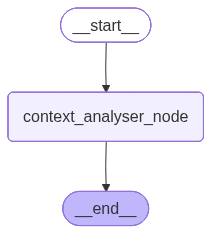

In [38]:
agent = workflow.compile()
agent

In [39]:
agent.invoke({
    "input": {},
    "raw_requirements": """
    We want to create an e-commerce platform that allows small to medium-sized businesses to easily set up their online stores. The platform should include features such as product listing, shopping cart functionality, payment integration, and user authentication. The goal is to build a scalable and user-friendly application within a budget of $50,000 and a timeline of 6 months. Our team consists of 5 members with experience in web development.
    """
})

{'input': {},
 'raw_requirements': '\n    We want to create an e-commerce platform that allows small to medium-sized businesses to easily set up their online stores. The platform should include features such as product listing, shopping cart functionality, payment integration, and user authentication. The goal is to build a scalable and user-friendly application within a budget of $50,000 and a timeline of 6 months. Our team consists of 5 members with experience in web development.\n    ',
 'structured_context': {'project_type': 'E-commerce Platform',
  'goals': ['Allow small to medium-sized businesses to easily set up their online stores',
   'Build a scalable and user-friendly application'],
  'features': ['Product Listing',
   'Shopping Cart Functionality',
   'Payment Integration',
   'User Authentication'],
  'target_users': 'Small to medium-sized businesses',
  'budget': '$50,000',
  'timeline': '6 months',
  'team_size': 5,
  'missing_information': [],
  'provided_missing_detail

Node 2 - Architecture Selector

In [40]:
from pydantic import BaseModel
from typing import List

class ArchitectureOutput(BaseModel):
    architecture_pattern: str
    reasoning: str

In [41]:
architecture_llm = llm.with_structured_output(ArchitectureOutput)

In [43]:
def architecture_selector_node(state: AgentState):

    context = state["structured_context"]

    prompt = f"""
You are a senior system architect.

Based on the following project context, select the most appropriate
software architecture pattern.

Available patterns:
- Modular Monolith
- Microservices
- Event Driven
- Serverless

Context:
{context}

Return reasoning and the selected architecture pattern.
"""

    response = architecture_llm.invoke(prompt)
    result = response.model_dump() if isinstance(response, ArchitectureOutput) else {}

    return {
        "architecture_pattern": {
            "pattern": result.get("architecture_pattern"),
            "reasoning": result.get("reasoning")
        }
    }

In [48]:
architecture_selector_node({
    "input": {},
    "raw_requirements": """
    We want to create an e-commerce platform that allows small to medium-sized businesses to easily set up their online stores. The platform should include features such as product listing, shopping cart functionality, payment integration, and user authentication. The goal is to build a scalable and user-friendly application within a budget of $50,000 and a timeline of 6 months. Our team consists of 5 members with experience in web development.
    """,
    "structured_context": {
        "project_type": "e-commerce platform",
        "goals": ["allow businesses to set up online stores", "build a scalable and user-friendly application"],
        "features": ["product listing", "shopping cart functionality", "payment integration", "user authentication"],
        "target_users": "small to medium-sized businesses",
        "budget": "$50,000",
        "timeline": "6 months",
        "team_size": 5,
        "missing_information": [],
        "provided_missing_details": {}
    }
})

{'architecture_pattern': {'pattern': 'Modular Monolith',
  'reasoning': 'The project is an e-commerce platform aimed at small to medium-sized businesses, with a moderate budget and timeline. A Modular Monolith architecture is suitable here because it allows for a well-structured application that can be developed and deployed relatively quickly by a small team. It offers better maintainability and testability than a traditional monolith, and it provides a foundation for future scaling or migration to microservices if needed. Microservices would likely be too complex and costly given the budget and timeline. Event-driven and serverless architectures, while scalable, might also introduce unnecessary complexity for the initial phase of this project.'}}

Node 3 - Service Decomposition

In [49]:
class ServiceItem(BaseModel):
    name: str
    responsibility: str

class ServicesOutput(BaseModel):
    services: List[ServiceItem]

In [50]:
services_llm = llm.with_structured_output(ServicesOutput)

In [51]:
def service_decomposition_node(state: AgentState):

    context = state["structured_context"]
    architecture = state["architecture_pattern"]

    prompt = f"""
You are a system design expert.

Break the system into logical services/modules.

Architecture Pattern:
{architecture}

Project Context:
{context}

Each service must include:
- name
- responsibility
"""

    response = services_llm.invoke(prompt)
    result = response.model_dump() if isinstance(response, ServicesOutput) else {}

    services = [service for service in result.get("services", [])]

    return {"services": services}

In [52]:
service_decomposition_node({
    "input": {},
    "raw_requirements": """
    We want to create an e-commerce platform that allows small to medium-sized businesses to easily set up their online stores. The platform should include features such as product listing, shopping cart functionality, payment integration, and user authentication. The goal is to build a scalable and user-friendly application within a budget of $50,000 and a timeline of 6 months. Our team consists of 5 members with experience in web development.
    """,
    "structured_context": {
        "project_type": "e-commerce platform",
        "goals": ["allow businesses to set up online stores", "build a scalable and user-friendly application"],
        "features": ["product listing", "shopping cart functionality", "payment integration", "user authentication"],
        "target_users": "small to medium-sized businesses",
        "budget": "$50,000",
        "timeline": "6 months",
        "team_size": 5,
        "missing_information": [],
        "provided_missing_details": {}
    },
    "architecture_pattern": {
        "pattern": "Modular Monolith",
        "reasoning": "The project is an e-commerce platform aimed at small to medium-sized businesses, with a moderate budget and timeline. A Modular Monolith architecture is suitable here because it allows for a well-structured application that can be developed and deployed relatively quickly by a small team. It offers better maintainability and testability than a traditional monolith, and it provides a foundation for future scaling or migration to microservices if needed. Microservices would likely be too complex and costly given the budget and timeline. Event-driven and serverless architectures, while scalable, might also introduce unnecessary complexity for the initial phase of this project."
    }
})

{'services': [{'name': 'User Management',
   'responsibility': 'Handles user authentication, authorization, and profile management.'},
  {'name': 'Product Catalog',
   'responsibility': 'Manages product information, categories, and inventory.'},
  {'name': 'Order Management',
   'responsibility': 'Processes orders, tracks order status, and manages order history.'},
  {'name': 'Shopping Cart',
   'responsibility': 'Manages user shopping carts, including adding/removing items and calculating totals.'},
  {'name': 'Payment Gateway Integration',
   'responsibility': 'Integrates with third-party payment providers to process transactions.'},
  {'name': 'Storefront',
   'responsibility': 'Provides the user interface for customers to browse products and make purchases.'},
  {'name': 'Admin Panel',
   'responsibility': 'Allows businesses to manage their stores, products, orders, and customer data.'}]}

Node 4 - Database Design

In [ ]:
from typing import Dict, Tuple

class Entity(BaseModel):
    name: str
    description: str

class ServiceDatabase(BaseModel):
    service_name: str
    database_type: str  # SQL / NoSQL / Cache
    technology: str
    entities: List[Entity]
    relationships: Dict[str, Tuple[str, str, str]]
    partition_strategy: str

class DatabaseOutput(BaseModel):
    database_design: List[ServiceDatabase]

database_llm = llm.with_structured_output(DatabaseOutput)

In [72]:
def database_design_node(state: AgentState):

    services = state["services"]
    context = state["structured_context"]

    prompt = f"""
You are a senior backend architect.

Design the database layer for each service.

Services:
{services}

Project Context:
{context}

For each service provide:

1. database_type (SQL / NoSQL / Cache)
2. technology (PostgreSQL, MongoDB, Cassandra, Redis etc.)
3. entities or tables
4. relationships between entities (entity1: entity2, relation_name, cardinality)
5. partition strategy

Rules:
- SQL for relational data
- NoSQL for large scale distributed data
- Redis for caching or sessions
"""

    response = database_llm.invoke(prompt)
    result = response.model_dump() if isinstance(response, DatabaseOutput) else {}

    db_design = [item.model_dump() for item in result.get("database_design", [])]

    return {
      "database_design": db_design
    }

In [73]:
database_design_node({
    "input": {},
    "structured_context": {
        "project_type": "e-commerce platform",
        "goals": ["allow businesses to set up online stores", "build a scalable and user-friendly application"],
        "features": ["product listing", "shopping cart functionality", "payment integration", "user authentication"],
        "target_users": "small to medium-sized businesses",
        "budget": "$50,000",
        "timeline": "6 months",
        "team_size": 5,
        "missing_information": [],
        "provided_missing_details": {}
    },
    "services": [
        {"name": "Product Service", "responsibility": "Manage product listings and details"},
        {"name": "Cart Service", "responsibility": "Handle shopping cart functionality"},
        {"name": "Payment Service", "responsibility": "Integrate payment processing"},
        {"name": "User Service", "responsibility": "Manage user authentication and profiles"}
    ]
})

{'database_design': []}

Node 5 - API Design

In [56]:
class APIEndpoint(BaseModel):
    service: str
    method: str
    path: str
    description: str

class APIOutput(BaseModel):
    api_design: List[APIEndpoint]

api_llm = llm.with_structured_output(APIOutput)

In [58]:
def api_design_node(state: AgentState):

    services = state["services"]

    prompt = f"""
Design core REST APIs for the following services.

Services:
{services}

Each API should include:
- service
- HTTP method
- path
- description
"""

    response = api_llm.invoke(prompt)
    result = response.model_dump() if isinstance(response, APIOutput) else {}

    apis = [api for api in result.get("api_design", [])]

    return {"api_design": apis}

In [59]:
api_design_node({
    "input": {},
    "services": [
        {"name": "Product Service", "responsibility": "Manage product listings and details"},
        {"name": "Cart Service", "responsibility": "Handle shopping cart functionality"},
        {"name": "Payment Service", "responsibility": "Integrate payment processing"},
        {"name": "User Service", "responsibility": "Manage user authentication and profiles"}
    ]
})

{'api_design': [{'service': 'Product Service',
   'method': 'GET',
   'path': '/products',
   'description': 'Retrieve a list of all products'},
  {'service': 'Product Service',
   'method': 'GET',
   'path': '/products/{id}',
   'description': 'Retrieve details of a specific product'},
  {'service': 'Product Service',
   'method': 'POST',
   'path': '/products',
   'description': 'Create a new product listing'},
  {'service': 'Product Service',
   'method': 'PUT',
   'path': '/products/{id}',
   'description': 'Update an existing product listing'},
  {'service': 'Product Service',
   'method': 'DELETE',
   'path': '/products/{id}',
   'description': 'Delete a product listing'},
  {'service': 'Cart Service',
   'method': 'GET',
   'path': '/cart/{userId}',
   'description': "Retrieve the user's shopping cart"},
  {'service': 'Cart Service',
   'method': 'POST',
   'path': '/cart/{userId}/items',
   'description': 'Add an item to the shopping cart'},
  {'service': 'Cart Service',
   'me

Node 6 - Infrastructure Design

In [ ]:
class InfrastructureOutput(BaseModel):
    infrastructure: Dict[str, str]
    deployment_architecture: str
    scaling_strategy: str
    observability_stack: List[str]

infrastructure_llm = llm.with_structured_output(InfrastructureOutput)

In [74]:
def infrastructure_node(state: AgentState):

    context = state["structured_context"]
    architecture = state["architecture_pattern"]
    services = state["services"]

    prompt = f"""
Design infrastructure components for the system.

Architecture Pattern:
{architecture}

Services:
{services}

Context:
{context}

Provide:

1. infrastructure components:
   - load_balancer
   - api_gateway
   - container_platform
   - cache
   - message_queue
   - object_storage

2. deployment_architecture description
3. scaling_strategy
4. observability_stack (monitoring/logging tools)
"""

    response = infrastructure_llm.invoke(prompt)
    result = response.model_dump() if isinstance(response, InfrastructureOutput) else {}

    return {
        "infrastructure": result.get("infrastructure", {}),
        "deployment_architecture": result.get("deployment_architecture", ""),
        "scaling_strategy": result.get("scaling_strategy", ""),
        "observability_stack": result.get("observability_stack", []),
    }

In [75]:
infrastructure_node({
    "input": {},
    "structured_context": {
        "project_type": "e-commerce platform",
        "goals": ["allow businesses to set up online stores", "build a scalable and user-friendly application"],
        "features": ["product listing", "shopping cart functionality", "payment integration", "user authentication"],
        "target_users": "small to medium-sized businesses",
        "budget": "$50,000",
        "timeline": "6 months",
        "team_size": 5,
        "missing_information": [],
        "provided_missing_details": {}
    },
    "architecture_pattern": {
        "pattern": "Modular Monolith",
        "reasoning": "The project is an e-commerce platform aimed at small to medium-sized businesses, with a moderate budget and timeline. A Modular Monolith architecture is suitable here because it allows for a well-structured application that can be developed and deployed relatively quickly by a small team."
    },
    "services": [
        {"name": "Product Service", "responsibility": "Manage product listings and details"},
        {"name": "Cart Service", "responsibility": "Handle shopping cart functionality"},
        {"name": "Payment Service", "responsibility": "Integrate payment processing"},
        {"name": "User Service", "responsibility": "Manage user authentication and profiles"}
    ]
})

{'infrastructure': {},
 'deployment_architecture': '',
 'scaling_strategy': '',
 'observability_stack': []}